In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [7]:
data = pd.read_csv("class.csv")
print("Original columns:\n", data.columns)
print("\nShape:", data.shape)

Original columns:
 Index(['Class_Number', 'Number_Of_Animal_Species_In_Class', 'Class_Type',
       'Animal_Names'],
      dtype='object')

Shape: (7, 4)


In [8]:
name_col = None
for c in data.columns:
    if "name" in c.lower():
        name_col = c
        break

In [9]:
X = data.select_dtypes(include=[np.number]).copy()


In [10]:
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

In [11]:
print("\nNumeric columns used for clustering:\n", X.columns.tolist())


Numeric columns used for clustering:
 ['Class_Number', 'Number_Of_Animal_Species_In_Class']


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
linked = linkage(X_scaled, method="ward")

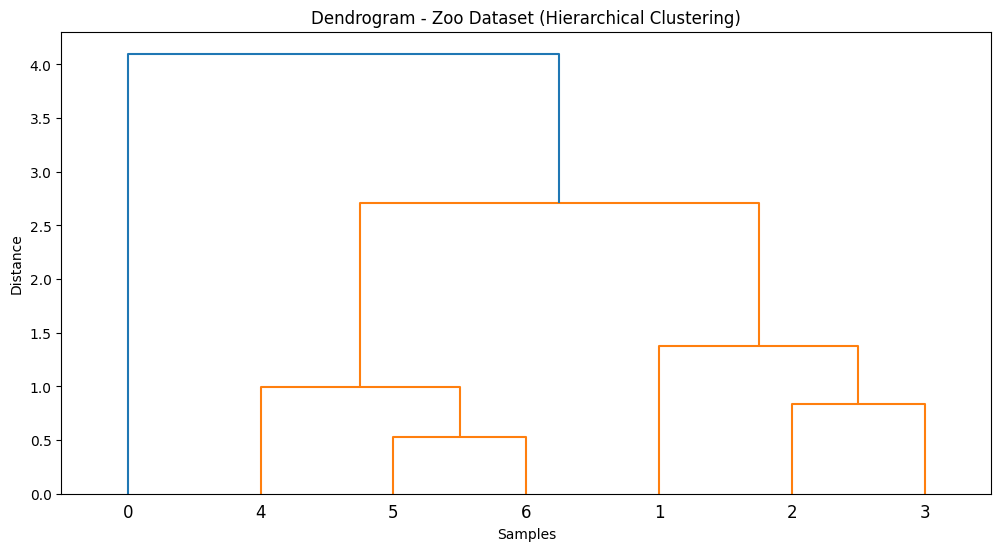

In [14]:
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram - Zoo Dataset (Hierarchical Clustering)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [15]:
model = AgglomerativeClustering(n_clusters=7, linkage="ward")
labels = model.fit_predict(X_scaled)

In [16]:
data["Cluster"] = labels

In [17]:
print("\nCluster counts:")
print(data["Cluster"].value_counts())



Cluster counts:
Cluster
3    1
4    1
5    1
6    1
1    1
2    1
0    1
Name: count, dtype: int64


In [18]:
if name_col is not None:
    print("\nSample output:")
    print(data[[name_col, "Cluster"]].head(10))
else:
    print("\nSample output:")
    print(data[["Cluster"]].head(10))


Sample output:
                                        Animal_Names  Cluster
0  aardvark, antelope, bear, boar, buffalo, calf,...        3
1  chicken, crow, dove, duck, flamingo, gull, haw...        4
2    pitviper, seasnake, slowworm, tortoise, tuatara        5
3  bass, carp, catfish, chub, dogfish, haddock, h...        6
4                             frog, frog, newt, toad        1
5  flea, gnat, honeybee, housefly, ladybird, moth...        2
6  clam, crab, crayfish, lobster, octopus, scorpi...        0


In [19]:
data.to_csv("zoo_clustered.csv", index=False)
print("\nSaved: zoo_clustered.csv")


Saved: zoo_clustered.csv
